In [2]:
# ===============================
# ETAPE 1 : IMPORTATION DES LIBRAIRIES
# ===============================
# Gestion des fichiers et dossiers
import os
import zipfile
import random

# Calcul scientifique
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning - TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Évaluation
from sklearn.metrics import confusion_matrix, classification_report

print("✅ Librairies importées avec succès")


✅ Librairies importées avec succès


In [3]:
# ===============================
# ETAPE 2 : CONNEXION AU DRIVE ET EXTRACTION DU DATASET
# ===============================
from google.colab import drive

# Nom du dossier partagé dans Google Drive
nom_dossier_drive = 'Projet_CNN'
nom_fichier_zip = 'emotions3.zip'

# Dossier d'extraction local (rapide)
dossier_extraction = '/content/dataset_emotions'

print("🔗 Connexion à Google Drive...")
drive.mount('/content/drive')

chemin_zip = f'/content/drive/MyDrive/{nom_dossier_drive}/{nom_fichier_zip}'

# Vérification et extraction
if os.path.exists(chemin_zip):
    print("✅ Dataset trouvé dans Drive")

    if not os.path.exists(dossier_extraction):
        print("📦 Extraction du dataset...")
        with zipfile.ZipFile(chemin_zip, 'r') as zip_ref:
            zip_ref.extractall(dossier_extraction)
        print("🎉 Extraction terminée")
    else:
        print("📂 Dataset déjà extrait")
else:
    print("❌ Fichier introuvable dans Drive")


🔗 Connexion à Google Drive...
Mounted at /content/drive
✅ Dataset trouvé dans Drive
📦 Extraction du dataset...
🎉 Extraction terminée


In [4]:
# ===============================
# ETAPE 3 : DÉTECTION DES DOSSIERS TRAIN / TEST
# ===============================
train_dir, test_dir = None, None

for root, dirs, files in os.walk(dossier_extraction):
    for d in dirs:
        if d.lower() in ['train', 'training']:
            train_dir = os.path.join(root, d)
        elif d.lower() in ['test', 'testing', 'validation']:
            test_dir = os.path.join(root, d)

print("📁 Train :", train_dir)
print("📁 Test  :", test_dir)


📁 Train : /content/dataset_emotions/emotions/train
📁 Test  : /content/dataset_emotions/emotions/test


In [5]:
# ===============================
# ETAPE 4 : PARAMÈTRES GLOBAUX
# ===============================
IMG_SIZE = 96        # Taille des images
BATCH_SIZE = 32      # Taille du batch
EPOCHS = 15          # Nombre maximal d'époques

print("⚙️ Paramètres configurés")


⚙️ Paramètres configurés


In [6]:
# ===============================
# ETAPE 5 : DATA AUGMENTATION
# ===============================
# Augmentation pour améliorer la généralisation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Pas d'augmentation pour le test
test_datagen = ImageDataGenerator(rescale=1./255)

print("🧠 Data augmentation activée")


🧠 Data augmentation activée


In [7]:
# ===============================
# ETAPE 6 : CHARGEMENT DES IMAGES
# ===============================
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

emotion_labels = list(train_generator.class_indices.keys())
num_classes = len(emotion_labels)

print("🎭 Classes détectées :", emotion_labels)


Found 33904 images belonging to 5 classes.
Found 8475 images belonging to 5 classes.
Found 5341 images belonging to 5 classes.
🎭 Classes détectées : ['colere', 'joie', 'neutre', 'peur', 'tristesse']


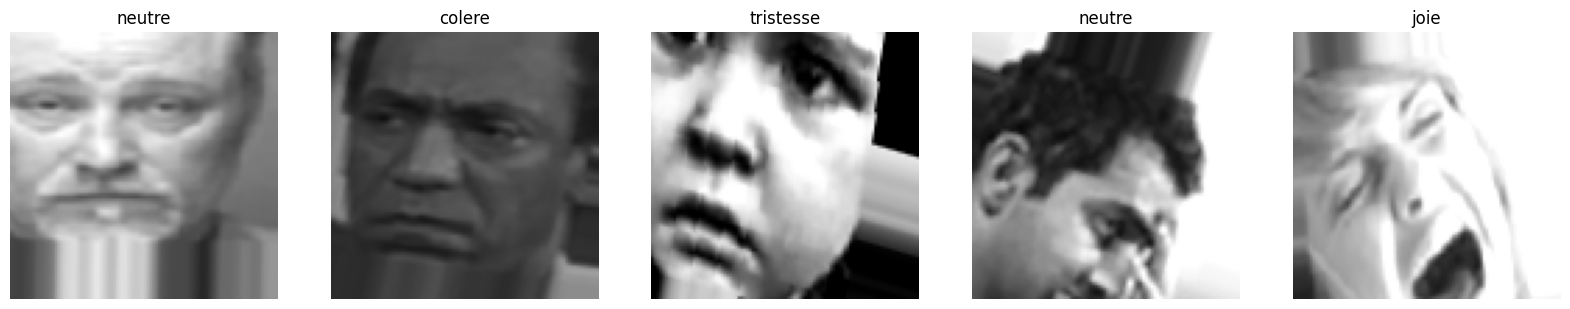

In [8]:
# ===============================
# ETAPE 7 : VISUALISATION DES IMAGES AUGMENTÉES
# ===============================
images, labels = next(train_generator)

plt.figure(figsize=(20,5))
for i in range(5):
    ax = plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title(emotion_labels[np.argmax(labels[i])])
    plt.axis("off")
plt.show()


In [48]:
# --- Création du modèle CNN (Transfer Learning) ---

# Chargement de la base MobileNetV2
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                         include_top=False,
                         weights='imagenet')

# Dégel partiel pour le Fine-Tuning (car dataset > 5000 images)
base_model.trainable = True
# On gèle les 80 premières couches (formes simples)
for layer in base_model.layers[:80]:
    layer.trainable = False


# Tête de classification
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compiler le modèle
# Learning rate faible (1e-4) pour ne pas brusquer le modèle pré-entraîné
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)


model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 2,368,005 (9.03 MB)

 Non-trainable params: 219,200 (856.25 KB)

In [16]:
print("Début de l'entraînement (15 époques)...")
# Note : Avec beaucoup de données, chaque époque durera un peu plus longtemps
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)
print("Terminé !")

Début de l'entraînement (15 époques)...
Epoch 1/15
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 212s 176ms/step - accuracy: 0.4644 - loss: 1.3469 - val_accuracy: 0.5532 - val_loss: 1.2589
Epoch 2/15
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 148s 140ms/step - accuracy: 0.6569 - loss: 0.8646 - val_accuracy: 0.7180 - val_loss: 0.7775
Epoch 3/15
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 154s 145ms/step - accuracy: 0.7138 - loss: 0.7450 - val_accuracy: 0.7181 - val_loss: 0.8638
Epoch 4/15
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 148s 140ms/step - accuracy: 0.7366 - loss: 0.6827 - val_accuracy: 0.7758 - val_loss: 0.6720
Epoch 5/15
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 147s 138ms/step - accuracy: 0.7682 - loss: 0.6122 - val_accuracy: 0.7543 - val_loss: 0.8295
Epoch 6/15
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 147s 138ms/step - accuracy: 0.7733 - loss: 0.5919 - val_accuracy: 0.7968 - val_loss: 0.7550
Epoch 7/15
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 147s 138ms/step - accuracy: 0.7844 - loss: 0.5572 - val_accuracy: 0.7738 - val_loss: 0.7995
Epoch 8/15
1060/1060 ━

In [1]:
# Récupération des données de l'historique
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 6))

# --- GRAPHIQUE 1 : PRÉCISION (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Courbe de Précision')
plt.legend(loc='lower right')
plt.grid(True)

# --- GRAPHIQUE 2 : PERTE (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Courbe de Perte')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

NameError: name 'history' is not defined

--- ÉVALUATION FINALE SUR LE DATASET DE TEST ---
167/167 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.7690 - loss: 0.9975

📉 Perte Finale (Loss)     : 0.8902
🎯 Précision Finale (Accuracy) : 76.76 %

Calcul de la Matrice de Confusion...
167/167 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step


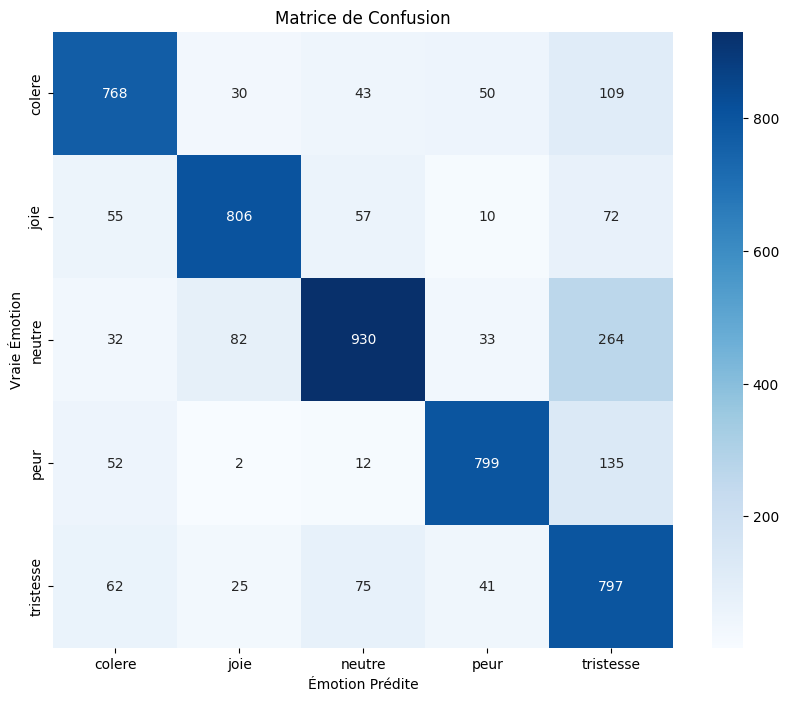

              precision    recall  f1-score   support

      colere       0.79      0.77      0.78      1000
        joie       0.85      0.81      0.83      1000
      neutre       0.83      0.69      0.76      1341
        peur       0.86      0.80      0.83      1000
   tristesse       0.58      0.80      0.67      1000

    accuracy                           0.77      5341
   macro avg       0.78      0.77      0.77      5341
weighted avg       0.79      0.77      0.77      5341



In [18]:
print("--- ÉVALUATION FINALE SUR LE DATASET DE TEST ---")

# On s'assure d'utiliser le générateur de test
results = model.evaluate(test_generator)
print(f"\n📉 Perte Finale (Loss)     : {results[0]:.4f}")
print(f"🎯 Précision Finale (Accuracy) : {results[1]*100:.2f} %")

# 1. Faire les prédictions sur tout le dossier de test
print("\nCalcul de la Matrice de Confusion...")
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# 3. Créer la matrice
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Matrice de Confusion')
plt.ylabel('Vraie Émotion')
plt.xlabel('Émotion Prédite')
plt.show()

# Rapport détaillé
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

Test sur 5 images aléatoires du dataset de TEST...


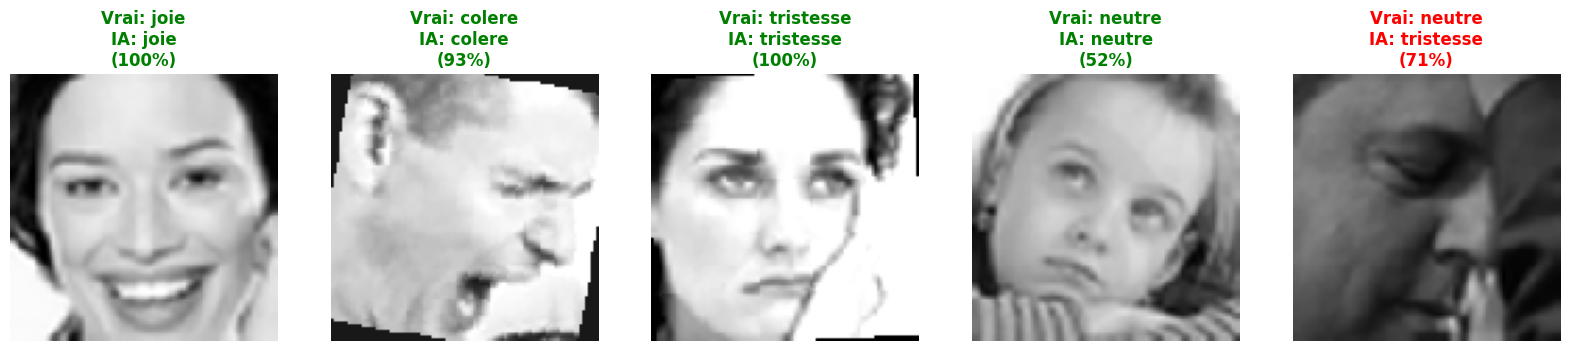

In [29]:
print("Test sur 5 images aléatoires du dataset de TEST...")
plt.figure(figsize=(20, 5))

for i in range(5):
    # Choix aléatoire d'une classe puis d'une image
    true_label = random.choice(class_labels)
    folder_path = os.path.join(test_dir, true_label)

    if not os.path.exists(folder_path): continue

    rand_img = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, rand_img)

    # Préparation
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb')
    img_arr = image.img_to_array(img)
    img_arr = np.expand_dims(img_arr, axis=0) / 255.0

    # Prediction
    pred = model.predict(img_arr, verbose=0)
    pred_label = class_labels[np.argmax(pred)]
    confidence = np.max(pred)

    # Affichage
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
    col = 'green' if true_label == pred_label else 'red'
    plt.title(f"Vrai: {true_label}\nIA: {pred_label}\n({confidence*100:.0f}%)", color=col, fontweight='bold')

plt.show()

In [1]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = '📸 PRENDRE PHOTO';
      capture.style.padding = '20px'; capture.style.fontSize = '20px';
      capture.style.backgroundColor = '#e91e63'; capture.style.color = 'white';
      capture.style.border = 'none'; capture.style.borderRadius = '8px';
      div.appendChild(capture);
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div); div.appendChild(video);
      video.srcObject = stream;
      await video.play();
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      await new Promise((resolve) => capture.onclick = resolve);
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth; canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop(); div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f: f.write(binary)
  return filename



face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

try:
  print("Faites une expression (Joie, Colère, Tristesse...)")
  filename = take_photo()

  # Lire l'image
  img_bgr = cv2.imread(filename)
  img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

  faces = face_cascade.detectMultiScale(gray, 1.3, 5)

  if len(faces) == 0:
    print("❌ Aucun visage détecté")
  else:
    for (x, y, w, h) in faces:
      face = img_rgb[y:y+h, x:x+w]
      face_resized = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
      face_resized = face_resized / 255.0
      face_input = np.expand_dims(face_resized, axis=0)

      pred = model.predict(face_input)
      idx = np.argmax(pred)
      label = emotion_labels[idx]
      conf = pred[0][idx]

      # Affichage
      plt.figure(figsize=(6,6))
      plt.imshow(img_rgb)
      plt.axis('off')
      plt.title(f"{label.upper()} ({conf*100:.1f}%)",
                fontsize=18, fontweight='bold', color='purple')
      plt.show()

      # Histogramme
      plt.bar(emotion_labels, pred[0], color='cornflowerblue')
      plt.title("Probabilités par émotion")
      plt.xticks(rotation=45)
      plt.show()

except Exception as e:
  print(f"Erreur Webcam : {e}")


Faites une expression (Joie, Colère, Tristesse...)


<IPython.core.display.Javascript object>

Erreur Webcam : name 'IMG_SIZE' is not defined
